In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import zscore
from sklearn.impute import SimpleImputer

In [2]:
participants_file = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\OpenNeuro\Word_Reading_childrenadolescents_Dyslexia\participants.tsv"

participants_df = pd.read_csv(participants_file, sep='\t')  # '\t' for TSV

In [3]:
# Show the first few rows
participants_df.head()

,participant_id,birthdate,ses-date_ST,ses-date_MRI_D1,ses-date_MRI_D2,ses-date_MRI_D3
0,sub-1002,2/14/1901,1/19/1917,3/13/1917,3/14/1917,3/15/1917
1,sub-1076,1/15/1900,9/12/1912,4/3/1912,4/11/1912,7/11/1912
2,sub-1077,10/21/1916,1/25/1930,11/23/1929,12/22/1929,NaN
3,sub-1078,10/15/1951,8/13/1962,6/11/1962,7/10/1962,NaN
4,sub-1079,5/17/1983,6/5/1994,6/2/1994,6/5/1994,12/4/1994


In [4]:
# Show column names
participants_df.columns

Index(['participant_id', 'birthdate', 'ses-date_ST', 'ses-date_MRI_D1',
       'ses-date_MRI_D2', 'ses-date_MRI_D3'],
      dtype='object')

In [5]:
# Get basic info about the dataframe
participants_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   participant_id   83 non-null     object
 1   birthdate        83 non-null     object
 2   ses-date_ST      80 non-null     object
 3   ses-date_MRI_D1  82 non-null     object
 4   ses-date_MRI_D2  77 non-null     object
 5   ses-date_MRI_D3  12 non-null     object
dtypes: object(6)
memory usage: 4.0+ KB


In [6]:
phenotype_folder = r"\\?\C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\OpenNeuro\Word_Reading_childrenadolescents_Dyslexia\word_reading\ds006239-main\phenotype"

In [7]:
for f in os.listdir(phenotype_folder):
    print(f)


amtocs.json
amtocs.tsv
arizona.json
arizona.tsv
asl-pat.json
asl-pat.tsv
audiology.json
audiology.tsv
background_survey.json
background_survey.tsv
celf-5.json
celf-5.tsv
corsi.json
corsi.tsv
ctopp-2.json
ctopp-2.tsv
dmorph.json
dmorph.tsv
eligibility_survey.json
eligibility_survey.tsv
kbit.json
kbit.tsv
piat.json
piat.tsv
toswrf-2.json
toswrf-2.tsv
video_interview_survey.json
video_interview_survey.tsv
wisc-v_backwarddigitspan.json
wisc-v_backwarddigitspan.tsv
wj-iii.json
wj-iii.tsv


In [8]:
import os

for f in os.listdir(phenotype_folder):
    print(repr(f))

'amtocs.json'
'amtocs.tsv'
'arizona.json'
'arizona.tsv'
'asl-pat.json'
'asl-pat.tsv'
'audiology.json'
'audiology.tsv'
'background_survey.json'
'background_survey.tsv'
'celf-5.json'
'celf-5.tsv'
'corsi.json'
'corsi.tsv'
'ctopp-2.json'
'ctopp-2.tsv'
'dmorph.json'
'dmorph.tsv'
'eligibility_survey.json'
'eligibility_survey.tsv'
'kbit.json'
'kbit.tsv'
'piat.json'
'piat.tsv'
'toswrf-2.json'
'toswrf-2.tsv'
'video_interview_survey.json'
'video_interview_survey.tsv'
'wisc-v_backwarddigitspan.json'
'wisc-v_backwarddigitspan.tsv'
'wj-iii.json'
'wj-iii.tsv'


In [9]:
# Dictionary to store dataframes
phenotype_data = {}

# Loop through all files in the folder
for file in os.listdir(phenotype_folder):
    if file.endswith(".tsv"):
        print(file)
        file_path = os.path.join(phenotype_folder, file)
        df = pd.read_csv(file_path, sep='\t')
        phenotype_data[file] = df  # Store dataframe with filename as key

# Check which files were loaded
print("TSV files loaded:", list(phenotype_data.keys()))

# Preview the first few rows of the first file
first_file = list(phenotype_data.keys())[0]
phenotype_data[first_file].head()

amtocs.tsv
arizona.tsv
asl-pat.tsv
audiology.tsv
background_survey.tsv
celf-5.tsv
corsi.tsv
ctopp-2.tsv
dmorph.tsv
eligibility_survey.tsv
kbit.tsv
piat.tsv
toswrf-2.tsv
video_interview_survey.tsv
wisc-v_backwarddigitspan.tsv
wj-iii.tsv
TSV files loaded: ['amtocs.tsv', 'arizona.tsv', 'asl-pat.tsv', 'audiology.tsv', 'background_survey.tsv', 'celf-5.tsv', 'corsi.tsv', 'ctopp-2.tsv', 'dmorph.tsv', 'eligibility_survey.tsv', 'kbit.tsv', 'piat.tsv', 'toswrf-2.tsv', 'video_interview_survey.tsv', 'wisc-v_backwarddigitspan.tsv', 'wj-iii.tsv']


,participant_ID,AmToCS_Raw,AmToCS_Acc,AmToCS_RT,AmToCS_StS
0,sub-1002,19,0.54286,5088.53,82
1,sub-1076,19,0.54290,3964.60,83
2,sub-1077,14,0.40000,3807.40,68
3,sub-1078,13,0.37140,4111.10,73
4,sub-1079,13,0.37140,5298.40,61


In [10]:
# Check what was loaded
print(list(phenotype_data.keys()))

phenotype_data['amtocs.tsv'].head()

['amtocs.tsv', 'arizona.tsv', 'asl-pat.tsv', 'audiology.tsv', 'background_survey.tsv', 'celf-5.tsv', 'corsi.tsv', 'ctopp-2.tsv', 'dmorph.tsv', 'eligibility_survey.tsv', 'kbit.tsv', 'piat.tsv', 'toswrf-2.tsv', 'video_interview_survey.tsv', 'wisc-v_backwarddigitspan.tsv', 'wj-iii.tsv']


,participant_ID,AmToCS_Raw,AmToCS_Acc,AmToCS_RT,AmToCS_StS
0,sub-1002,19,0.54286,5088.53,82
1,sub-1076,19,0.54290,3964.60,83
2,sub-1077,14,0.40000,3807.40,68
3,sub-1078,13,0.37140,4111.10,73
4,sub-1079,13,0.37140,5298.40,61


## `amtocs.tsv` – Amherst Test of Cognitive Skills

| Column           | Description                   | Type        | What It Measures                | Importance                                         |
| ---------------- | ----------------------------- | ----------- | ------------------------------- | -------------------------------------------------- |
| `participant_ID` | Unique participant identifier | Categorical | Connects data across all tests  | For merging and subject alignment                  |
| `AmToCS_Raw`     | Raw total score               | Numeric     | Overall task performance        | Baseline cognitive score                           |
| `AmToCS_Acc`     | Accuracy rate (0–1)           | Numeric     | Proportion of correct responses | Indicates attention and comprehension              |
| `AmToCS_RT`      | Reaction time (ms)            | Numeric     | Processing speed                | Important for ADHD and cognitive speed differences |
| `AmToCS_StS`     | Standard score                | Numeric     | Normalized cognitive ability    | Used for between-subject comparisons               |


In [11]:
phenotype_data['asl-pat.tsv'].head()

,participant_ID,ASLPAT_Acc,ASLPAT_Rep
0,sub-1002,18.0,5.85
1,sub-1076,10.0,4.95
2,sub-1077,16.0,3.95
3,sub-1078,12.0,3.95
4,sub-1079,9.0,3.95


## `asl-pat.tsv` – American Sign Language Phonological Awareness Test

| Column           | Description                        | Type        | What It Measures                                | Importance                                             |
| ---------------- | ---------------------------------- | ----------- | ----------------------------------------------- | ------------------------------------------------------ |
| `participant_ID` | Unique subject ID                  | Categorical | Participant linkage                             | For merging                                            |
| `ASLPAT_Acc`     | Accuracy score                     | Numeric     | Correct responses in ASL phonological awareness | Measures linguistic processing, visual-spatial mapping |
| `ASLPAT_Rep`     | Representation or repetition score | Numeric     | How well signs are remembered/reproduced        | Indicates short-term memory and language integration   |


In [12]:
phenotype_data['arizona.tsv'].head()

,participant_ID,Arizona_Raw,Arizona_StS
0,sub-1002,100.0,>100
1,sub-1076,100.0,>100
2,sub-1077,NaN,NaN
3,sub-1078,100.0,>100
4,sub-1079,100.0,>100


## `arizona.tsv` – Arizona Reading Assessment

| Column           | Description        | Type           | What It Measures                                                     | Importance                                 |
| ---------------- | ------------------ | -------------- | -------------------------------------------------------------------- | ------------------------------------------ |
| `participant_ID` | Subject ID         | Categorical    | Participant identifier                                               | Used for linking                           |
| `Arizona_Raw`    | Raw test score     | Numeric        | Reading comprehension and decoding                                   | Reading ability                            |
| `Arizona_StS`    | Standardized score | String/Numeric | Normalized reading proficiency (sometimes categorical, e.g., “>100”) | Useful for identifying reading skill level |


In [13]:
phenotype_data['audiology.tsv'].head()

,participant_ID,Otoscopy,PT_screening_passed,SIN-List,SNR_A,SNR_B,AVG_SNR
0,sub-1002,NaN,yes,NaN,NaN,NaN,NaN
1,sub-1076,clear,yes,1A&1B,0.5,-1.5,-0.5
2,sub-1077,clear,yes,1A&1B,-0.5,-2.5,-1.5
3,sub-1078,clear,yes,1A&1B,0.5,1.5,1.0
4,sub-1079,clear,yes,1A&1B,0.5,1.5,1.0


## `audiology.tsv` – Hearing and Sound Perception

| Column                | Description                | Type        | What It Measures                 | Importance                                                 |
| --------------------- | -------------------------- | ----------- | -------------------------------- | ---------------------------------------------------------- |
| `participant_ID`      | Subject ID                 | Categorical | Links participant                | For merging                                                |
| `Otoscopy`            | Ear canal status           | String      | “clear” or “blocked”             | Physical hearing health                                    |
| `PT_screening_passed` | Pure-tone screening result | String      | “yes” or “no”                    | Baseline hearing ability                                   |
| `SIN-List`            | Speech-in-noise list used  | String      | Identifies testing list          | Controls for test version                                  |
| `SNR_A`, `SNR_B`      | Signal-to-noise ratios     | Numeric     | Sound discrimination under noise | Hearing processing ability                                 |
| `AVG_SNR`             | Mean signal-to-noise ratio | Numeric     | Average listening performance    | Important confound control in dyslexia or language studies |


In [14]:
phenotype_data['background_survey.tsv'].head()

,""" record_id""",guardian_live_with___1,guardian_live_with___2,guardian_live_with___3,guardian_live_with___4,guardian_live_with___5,guardian_live_with___6,guardian_live_with___7,guardian_live_with___8,guardian_live_with___9,...,adhd_question_9_v2,adhd_question_10_v2,adhd_question_11_v2,adhd_question_12_v2,adhd_question_13_v2,adhd_question_14_v2,adhd_question_15_v2,adhd_question_16_v2,adhd_question_17_v2,adhd_question_18_v2
0,sub-1002,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,sub-1076,0,0,0,1,0,0,0,0,0,...,1.0,0.0,1.0,2.0,0.0,3.0,1.0,2.0,1.0,1.0
2,sub-1077,1,0,0,1,0,0,0,0,0,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,sub-1078,1,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,sub-1079,1,0,0,1,0,0,0,0,0,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


## `background_survey.tsv` – Guardian, Household & ADHD Questionnaire

| Column                     | Description                             | Type         | What It Measures                          | Importance                                      |
| -------------------------- | --------------------------------------- | ------------ | ----------------------------------------- | ----------------------------------------------- |
| `"record_id"`              | Participant identifier                  | Categorical  | Connects to participant                   | Linking key                                     |
| `guardian_live_with___1–9` | Binary responses                        | Binary (0/1) | Indicates who the child lives with        | Socio-environmental background                  |
| `adhd_question_1_v2–18_v2` | Numeric Likert scale                    | Numeric      | ADHD-related behavior questionnaire items | Behavioral attention and impulsivity indicators |
| *(others)*                 | Household, education, socio-demographic | Mixed        | Contextual background                     | Used for correlation or control variables       |


background_survey.tsv — Demographic + ADHD Questionnaire

Contains 130+ columns such as:

Guardian/household info (guardian_live_with___*)

Education background

ADHD questions (adhd_question_*_v2)

🧩 Purpose: Collects socioeconomic, environmental, and behavioral factors.
📈 Importance: ADHD question responses help label ADHD traits; demographics can be used as confounding or control variables.

In [15]:
phenotype_data['celf-5.tsv'].head()

,participant_ID,CELF_SC_Raw,CELF_SC_SS,CELF_RS_Raw,CELF_RS_SS
0,sub-1002,69,105,25,105
1,sub-1076,59,100,26,100
2,sub-1077,69,115,25,115
3,sub-1078,69,130,25,130
4,sub-1079,53,95,26,95


## `celf-5.tsv` – Clinical Evaluation of Language Fundamentals (5th Ed.)

| Column           | Description                           | Type        | What It Measures                 | Importance                             |
| ---------------- | ------------------------------------- | ----------- | -------------------------------- | -------------------------------------- |
| `participant_ID` | Participant ID                        | Categorical | Linking key                      | For merging                            |
| `CELF_SC_Raw`    | Sentence Comprehension raw            | Numeric     | Understanding of spoken language | Core to dyslexia and language deficits |
| `CELF_SC_SS`     | Sentence Comprehension standard score | Numeric     | Age-normed comprehension         | Language ability measure               |
| `CELF_RS_Raw`    | Recalling Sentences raw               | Numeric     | Memory for language              | Verbal working memory                  |
| `CELF_RS_SS`     | Recalling Sentences standard score    | Numeric     | Age-normalized memory score      | Supports ADHD/dyslexia prediction      |


In [16]:
phenotype_data['corsi.tsv'].head()

,participant_ID,CORSI_span,CORSI_total
0,sub-1002,5,13
1,sub-1076,6,14
2,sub-1077,9,24
3,sub-1078,7,13
4,sub-1079,5,10


## `corsi.tsv` – Corsi Block-Tapping Task

| Column           | Description                      | Type        | What It Measures                        | Importance                             |
| ---------------- | -------------------------------- | ----------- | --------------------------------------- | -------------------------------------- |
| `participant_ID` | Participant ID                   | Categorical | Link to subject                         | Merging key                            |
| `CORSI_span`     | Maximum sequence length recalled | Numeric     | Spatial short-term memory capacity      | Working memory and attention           |
| `CORSI_total`    | Total correct trials             | Numeric     | Visuospatial working memory performance | Relates to ADHD and executive function |


In [17]:
phenotype_data['ctopp-2.tsv'].head()

,participant_ID,CTOPP-2_EL_Raw,CTOPP-2_EL_ScS,CTOPP-2_BW_Raw,CTOPP-2_BW_ScS,CTOPP-2_PI_Raw,CTOPP-2_PI_ScS,CTOPP-2_Comp
0,sub-1002,32,11,32,16,27,10,116
1,sub-1076,27,9,27,12,22,7,96
2,sub-1077,24,9,32,17,22,7,107
3,sub-1078,28,10,21,7,23,7,88
4,sub-1079,27,9,21,7,28,11,96


## `ctopp-2.tsv` – Comprehensive Test of Phonological Processing (2nd Ed.)

| Column                             | Description                       | Type        | What It Measures           | Importance                     |
| ---------------------------------- | --------------------------------- | ----------- | -------------------------- | ------------------------------ |
| `participant_ID`                   | Participant ID                    | Categorical | Subject link               | Merging                        |
| `CTOPP-2_EL_Raw`, `CTOPP-2_EL_ScS` | Elision task raw/standard         | Numeric     | Phonological awareness     | Dyslexia core feature          |
| `CTOPP-2_BW_Raw`, `CTOPP-2_BW_ScS` | Blending Words task               | Numeric     | Phonological synthesis     | Reading acquisition indicator  |
| `CTOPP-2_PI_Raw`, `CTOPP-2_PI_ScS` | Phoneme Isolation                 | Numeric     | Sound discrimination       | Early language processing      |
| `CTOPP-2_Comp`                     | Composite phonological processing | Numeric     | Overall phonological skill | Central for dyslexia detection |


In [18]:
phenotype_data['dmorph.tsv'].head()

,participant_ID,dmorph_acc,dmorph_rt
0,sub-1002,25,6967.88
1,sub-1076,27,4861.78
2,sub-1077,26,10136.70
3,sub-1078,12,15194.80
4,sub-1079,25,22252.70


## `dmorph.tsv` – Dynamic Morphology Task

| Column           | Description        | Type        | What It Measures         | Importance                                          |
| ---------------- | ------------------ | ----------- | ------------------------ | --------------------------------------------------- |
| `participant_ID` | Subject ID         | Categorical | Link across data         | For merging                                         |
| `dmorph_acc`     | Accuracy           | Numeric     | Morphological processing | Reading and grammar skill                           |
| `dmorph_rt`      | Reaction time (ms) | Numeric     | Processing speed         | Key cognitive timing variable for dyslexia and ADHD |


In [19]:
phenotype_data['eligibility_survey.tsv'].head()

,""" record_id""",child_biological_sex,child_gender,child_race___1,child_race___2,child_race___3,child_race___4,child_race___6,child_race___5,child_race___7,...,prev_diagnosed_conditions___9,prev_diagnosed_conditions___10,prev_diagnosed_conditions___11,prev_diagnosed_conditions___12,prev_diagnosed_conditions___13,prev_diagnosed_conditions___14,prev_diagnosed_conditions___15,prev_diagnosed_conditions___16,prev_diagnosed_conditions___18,prev_diagnosed_conditions___17
0,sub-1002,2,2.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,sub-1076,1,1.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,sub-1077,1,1.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,sub-1078,1,1.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,sub-1079,2,2.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


## `eligibility_survey.tsv`– Participant Eligibility Screening

| Column                   | Description                      | Type                | What It Measures                                          | Importance                                               |
| ------------------------ | -------------------------------- | ------------------- | --------------------------------------------------------- | -------------------------------------------------------- |
| `participant_ID`         | Subject identifier               | Categorical         | Link to other phenotype data                              | Merge key                                                |
| `eligible`               | Eligibility status               | Binary (`yes`/`no`) | Indicates whether participant meets inclusion criteria    | Ensures only valid participants are included in analysis |
| `inclusion_criteria_met` | Number of criteria met           | Numeric             | Quantifies how many inclusion requirements were satisfied | Helps track partial eligibility or reasons for exclusion |
| `exclusion_criteria_met` | Number of exclusion criteria met | Numeric             | Quantifies disqualifying factors                          | Ensures confounds are removed                            |
| `notes`                  | Free text notes                  | String              | Additional comments by the evaluator                      | Contextual info for any special cases or exclusions      |


In [20]:
phenotype_data['kbit.tsv'].head()

,participant_ID,KBIT_Matrices_Raw,KBIT_Nonverbal_StS
0,sub-1002,45,130
1,sub-1076,36,108
2,sub-1077,41,121
3,sub-1078,19,69
4,sub-1079,36,113


## `kbit.tsv` – Kaufman Brief Intelligence Test

| Column               | Description            | Type        | What It Measures     | Importance                                |
| -------------------- | ---------------------- | ----------- | -------------------- | ----------------------------------------- |
| `participant_ID`     | Subject ID             | Categorical | Link to subject      | Merging key                               |
| `KBIT_Matrices_Raw`  | Raw score for matrices | Numeric     | Non-verbal reasoning | General cognitive ability                 |
| `KBIT_Nonverbal_StS` | Standard score         | Numeric     | Age-normalized score | For IQ-based normalization and covariates |



In [21]:
phenotype_data['piat.tsv'].head()

,participant_ID,PIAT_Raw,PIAT_StS
0,sub-1002,84,95
1,sub-1076,81,106
2,sub-1077,92,116
3,sub-1078,85,120
4,sub-1079,63,96


## `piat.tsv` – Peabody Individual Achievement Test

| Column           | Description     | Type        | What It Measures     | Importance                    |
| ---------------- | --------------- | ----------- | -------------------- | ----------------------------- |
| `participant_ID` | Participant ID  | Categorical | Link to subject      | Merging key                   |
| `PIAT_Raw`       | Raw total score | Numeric     | Academic achievement | Baseline academic performance |
| `PIAT_StS`       | Standard score  | Numeric     | Age-normed score     | Reading/math skill reference  |




In [22]:
phenotype_data['toswrf-2.tsv'].head()

,participant_ID,TOSWRF-2_Test,TOSWRF-2_Raw,TOSWRF-2_StS
0,sub-1002,B,154,113
1,sub-1076,B,98,92
2,sub-1077,A,117,97
3,sub-1078,B,50,76
4,sub-1079,A,136,114


## `toswrf-2.tsv` – Test of Silent Word Reading Fluency (2nd Ed.)

| Column           | Description    | Type        | What It Measures               | Importance                      |
| ---------------- | -------------- | ----------- | ------------------------------ | ------------------------------- |
| `participant_ID` | Participant ID | Categorical | Link to subject                | Merging key                     |
| `TOSWRF-2_Test`  | Test version   | Categorical | Version control                | Consistency across participants |
| `TOSWRF-2_Raw`   | Raw score      | Numeric     | Number of words read correctly | Reading fluency                 |
| `TOSWRF-2_StS`   | Standard score | Numeric     | Age-normalized reading fluency | Dyslexia indicator              |

In [23]:
phenotype_data['video_interview_survey.tsv'].head()

,""" """" record_id""""""",name,birthday,household,from,date,object_naming,forward_ds,backward_ds,recall,body_parts,command,writing,drawing,mmc_score,dolch_correct,combine_score
0,sub-1002,3.0,5.0,3.0,3.0,4.0,4.0,5.0,4.0,4.0,6.0,4.0,2.0,2.0,37.0,21.0,58.0
1,sub-1076,3.0,5.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,6.0,4.0,2.0,2.0,36.0,21.0,57.0
2,sub-1077,3.0,5.0,3.0,3.0,4.0,4.0,5.0,4.0,4.0,6.0,4.0,2.0,2.0,37.0,21.0,58.0
3,sub-1078,3.0,5.0,3.0,3.0,3.0,4.0,5.0,3.0,4.0,6.0,4.0,2.0,2.0,36.0,20.0,56.0
4,sub-1079,3.0,5.0,3.0,3.0,3.0,4.0,5.0,3.0,4.0,6.0,4.0,2.0,2.0,37.0,21.0,58.0


## `video_interview_survey.tsv` – Cognitive and Motor Tasks

| Column                                                                                  | Description           | Type                | What It Measures             | Importance                        |
| --------------------------------------------------------------------------------------- | --------------------- | ------------------- | ---------------------------- | --------------------------------- |
| `" "" record_id"""`                                                                     | Participant ID        | Categorical         | Merging key                  | Subject alignment                 |
| `name, birthday, household, from, date`                                                 | Demographics          | Numeric/Categorical | Age, home environment        | Confound and background control   |
| `object_naming, forward_ds, backward_ds, recall, body_parts, command, writing, drawing` | Cognitive/motor tasks | Numeric             | Memory, naming, motor skills | ADHD and executive function proxy |
| `mmc_score, dolch_correct, combine_score`                                               | Composite scores      | Numeric             | Combined performance metrics | Key phenotype features            |


In [24]:
phenotype_data['wisc-v_backwarddigitspan.tsv'].head()

,participant_ID,Digit_Span,Digit_Total
0,sub-1002,8,23
1,sub-1076,5,10
2,sub-1077,5,10
3,sub-1078,5,10
4,sub-1079,5,11


## `wisc-v_backwarddigitspan.tsv` – WISC-V Backward Digit Span


| Column           | Description             | Type        | What It Measures    | Importance                  |
| ---------------- | ----------------------- | ----------- | ------------------- | --------------------------- |
| `participant_ID` | Subject ID              | Categorical | Merge key           | Linking participants        |
| `Digit_Span`     | Maximum digits recalled | Numeric     | Working memory span | ADHD and executive function |
| `Digit_Total`    | Total correct responses | Numeric     | Performance         | Memory performance metric   |


In [25]:
phenotype_data['wj-iii.tsv'].head()

,participant_ID,WJ-III_WordID_Raw,WJ-III_WordID_StS,WJ-III_ReadFluency_Raw,WJ-III_ReadFluency_StS
0,sub-1002,69,106.0,97,122.0
1,sub-1076,55,94.0,64,111.0
2,sub-1077,65,108.0,73,114.0
3,sub-1078,59,108.0,51,106.0
4,sub-1079,61,111.0,54,108.0


## `wj-iii.tsv` – Woodcock-Johnson III Reading

| Column                   | Description                   | Type        | What It Measures               | Importance               |
| ------------------------ | ----------------------------- | ----------- | ------------------------------ | ------------------------ |
| `participant_ID`         | Subject ID                    | Categorical | Merge key                      | Linking participants     |
| `WJ-III_WordID_Raw`      | Raw word identification score | Numeric     | Word reading ability           | Dyslexia measure         |
| `WJ-III_WordID_StS`      | Standardized score            | Numeric     | Age-normed reading             | Dyslexia assessment      |
| `WJ-III_ReadFluency_Raw` | Raw reading fluency score     | Numeric     | Number of words read correctly | Fluency metric           |
| `WJ-III_ReadFluency_StS` | Standardized score            | Numeric     | Age-normalized fluency         | Reading skill comparison |


| File                               | Assessment                                                          | Measures                                         | Interpretation / Use                                                                                      |
| ---------------------------------- | ------------------------------------------------------------------- | ------------------------------------------------ | --------------------------------------------------------------------------------------------------------- |
| **`amtocs.tsv`**                   | *American Test of Oral Comprehension of Syntax*                     | Accuracy, reaction time                          | Language comprehension — useful in dyslexia or language delay screening.                                  |
| **`asl-pat.tsv`**                  | *American Sign Language Production Assessment Test*                 | Accuracy, repetition                             | Evaluates expressive language & working memory.                                                           |
| **`arizona.tsv`**                  | *Arizona Articulation Proficiency Scale*                            | Raw & standard scores                            | Speech sound articulation — motor speech component in dyslexia/autism.                                    |
| **`audiology.tsv`**                | Hearing screening & SNR (signal-to-noise ratio)                     | Hearing clarity                                  | Ensures auditory deficits aren’t confounding reading or phonological deficits.                            |
| **`background_survey.tsv`**        | Family, demographic, and ADHD-related questions                     | ADHD screening + socioeconomic factors           | Very important for **phenotype labeling** (e.g., ADHD traits) and **covariates** (SES, family structure). |
| **`celf-5.tsv`**                   | *Clinical Evaluation of Language Fundamentals*                      | Sentence comprehension & recalling sentences     | Tests verbal reasoning and syntax — language-related cognitive skill.                                     |
| **`corsi.tsv`**                    | *Corsi Block-Tapping Test*                                          | Spatial working memory span                      | Tests **visuospatial working memory** — often weak in ADHD.                                               |
| **`ctopp-2.tsv`**                  | *Comprehensive Test of Phonological Processing*                     | Phonological awareness, memory, processing speed | One of the **core dyslexia indicators**.                                                                  |
| **`dmorph.tsv`**                   | Morphological awareness task                                        | Accuracy, reaction time                          | Understanding word structure — strongly tied to reading ability.                                          |
| **`kbit.tsv`**                     | *Kaufman Brief Intelligence Test*                                   | Nonverbal IQ                                     | General cognitive ability — useful as a control variable.                                                 |
| **`piat.tsv`**                     | *Peabody Individual Achievement Test*                               | Reading ability                                  | Direct reading assessment — highly relevant for dyslexia.                                                 |
| **`toswrf-2.tsv`**                 | *Test of Silent Word Reading Fluency*                               | Reading speed & fluency                          | Key measure of **reading automaticity**, another dyslexia marker.                                         |
| **`video_interview_survey.tsv`**   | Child performance tasks scored by experimenters                     | Memory, comprehension, naming, writing           | General language & cognitive composite.                                                                   |
| **`wisc-v_backwarddigitspan.tsv`** | *Wechsler Intelligence Scale for Children* (working memory subtest) | Digit span backward                              | **Verbal working memory** — important for ADHD studies.                                                   |
| **`wj-iii.tsv`**                   | *Woodcock–Johnson III Tests of Achievement*                         | Word ID & reading fluency                        | Another standardized **reading and literacy** measure.                                                    |


| File                             | Core Domain                              | Example Feature Type                              | Relevance                    |
| -------------------------------- | ---------------------------------------- | ------------------------------------------------- | ---------------------------- |
| **amtocs.tsv**                   | Grammar comprehension                    | Accuracy, Reaction Time                           | Dyslexia                     |
| **arizona.tsv**                  | Reading                                  | Word reading score                                | Dyslexia                     |
| **asl-pat.tsv**                  | Auditory memory / language repetition    | Accuracy, Repetition                              | Autism, Dyslexia             |
| **audiology.tsv**                | Hearing screening                        | SNR, Otoscopy, Pass/Fail                          | Control                      |
| **background_survey.tsv**        | ADHD & Demographics                      | ADHD questionnaire responses, guardian info       | ADHD                         |
| **celf-5.tsv**                   | Language comprehension & sentence recall | Standard and Raw Scores                           | Dyslexia, Autism             |
| **corsi.tsv**                    | Visuospatial working memory              | CORSI span, total score                           | ADHD                         |
| **ctopp-2.tsv**                  | Phonological processing                  | Composite, Raw, Scaled Scores                     | Dyslexia                     |
| **dmorph.tsv**                   | Morphological awareness                  | Accuracy, Reaction Time                           | Dyslexia, Autism             |
| **eligibility_survey.tsv**       | Participant screening & inclusion        | Eligibility responses                             | Control / Filtering          |
| **kbit.tsv**                     | Intelligence (IQ)                        | Nonverbal standard scores                         | Control (Cognitive baseline) |
| **piat.tsv**                     | Reading achievement                      | Reading comprehension scores                      | Dyslexia                     |
| **toswrf-2.tsv**                 | Reading fluency                          | Raw, Standard Scores                              | Dyslexia                     |
| **video_interview_survey.tsv**   | Behavioral / cognitive observation       | Object naming, recall, comprehension, total score | Autism, ADHD                 |
| **wisc-v_backwarddigitspan.tsv** | Verbal working memory                    | Digit Span, Total                                 | ADHD                         |
| **wj-iii.tsv**                   | Reading & fluency                        | Word identification, Reading fluency              | Dyslexia                     |


### Summary by Domain

| Domain                       | Related Files                                                                        | Target Disorders            |
| ---------------------------- | ------------------------------------------------------------------------------------ | --------------------------- |
| **Reading & Phonology**      | `arizona.tsv`, `ctopp-2.tsv`, `piat.tsv`, `toswrf-2.tsv`, `wj-iii.tsv`, `dmorph.tsv` | Dyslexia                    |
| **Language & Communication** | `amtocs.tsv`, `celf-5.tsv`, `asl-pat.tsv`, `video_interview_survey.tsv`              | Dyslexia, Autism            |
| **Memory & Cognition**       | `corsi.tsv`, `wisc-v_backwarddigitspan.tsv`, `kbit.tsv`                              | ADHD, Dyslexia              |
| **Behavior & Background**    | `background_survey.tsv`, `eligibility_survey.tsv`                                    | ADHD, Autism                |
| **Hearing Control**          | `audiology.tsv`                                                                      | Control / Quality assurance |


### Summary Insight

| Phenotype Domain            | Tests                                                         | Measures                            | Neuro/Cognitive Relevance                      |
| --------------------------- | ------------------------------------------------------------- | ----------------------------------- | ---------------------------------------------- |
| **Phonological & Language** | `ctopp-2`, `celf-5`, `arizona`, `wj-iii`, `piat`, `toswrf-2`  | Sound, comprehension, fluency       | Key for Dyslexia                               |
| **Memory & Attention**      | `wisc-v_backwarddigitspan`, `corsi`, `video_interview_survey` | Working memory, short-term recall   | ADHD-related                                   |
| **Cognitive Processing**    | `amtocs`, `kbit`, `dmorph`                                    | Reasoning, speed, accuracy          | General intelligence + cross-disorder variance |
| **Environmental Factors**   | `background_survey`, `audiology`                              | Socio-demographics, hearing ability | Confound control variables                     |



| Disorder     | Relevant Tests                             | Cognitive Domains Captured                                        |
| ------------ | ------------------------------------------ | ----------------------------------------------------------------- |
| **Dyslexia** | CTOPP-2, CELF-5, Arizona, AmToCS, dmorph   | Phonological processing, reading fluency, morphological awareness |
| **ADHD**     | Background survey (ADHD Qs), WISC-V, Corsi | Attention, working memory, impulsivity                            |
| **Autism**   | ASLPAT, CELF-5, dmorph, video interview    | Language pragmatics, social communication, comprehension          |


# Merge All files

In [26]:
tsv_files = [f for f in phenotype_data.keys() if f.endswith('.tsv')]

In [27]:
import pandas as pd

# Only TSV files
tsv_files = [f for f in phenotype_data.keys() if f.endswith('.tsv')]

# Step 1: Normalize participant ID column
for key in tsv_files:
    df = phenotype_data[key]
    
    # Find the column that contains 'id' (case-insensitive)
    id_cols = [c for c in df.columns if 'id' in c.lower()]
    
    if len(id_cols) == 0:
        print(f"No ID column found in {key}")
    else:
        # Rename the first ID-like column to 'participant_ID'
        df.rename(columns={id_cols[0]: 'participant_ID'}, inplace=True)
        phenotype_data[key] = df

# Step 2: Merge iteratively
merged_df = phenotype_data[tsv_files[0]]

for key in tsv_files[1:]:
    merged_df = pd.merge(
        merged_df,
        phenotype_data[key],
        on='participant_ID',
        how='outer'
    )

print(merged_df.shape)
merged_df.head()


(87, 244)


,participant_ID,AmToCS_Raw,AmToCS_Acc,AmToCS_RT,AmToCS_StS,Arizona_Raw,Arizona_StS,ASLPAT_Acc,ASLPAT_Rep,Otoscopy,...,drawing,mmc_score,dolch_correct,combine_score,Digit_Span,Digit_Total,WJ-III_WordID_Raw,WJ-III_WordID_StS,WJ-III_ReadFluency_Raw,WJ-III_ReadFluency_StS
0,sub-1002,19.0,0.54286,5088.53,82.0,100.0,>100,18.0,5.85,NaN,...,2.0,37.0,21.0,58.0,8.0,23.0,69.0,106.0,97.0,122.0
1,sub-1076,19.0,0.54290,3964.60,83.0,100.0,>100,10.0,4.95,clear,...,2.0,36.0,21.0,57.0,5.0,10.0,55.0,94.0,64.0,111.0
2,sub-1077,14.0,0.40000,3807.40,68.0,NaN,NaN,16.0,3.95,clear,...,2.0,37.0,21.0,58.0,5.0,10.0,65.0,108.0,73.0,114.0
3,sub-1078,13.0,0.37140,4111.10,73.0,100.0,>100,12.0,3.95,clear,...,2.0,36.0,20.0,56.0,5.0,10.0,59.0,108.0,51.0,106.0
4,sub-1079,13.0,0.37140,5298.40,61.0,100.0,>100,9.0,3.95,clear,...,2.0,37.0,21.0,58.0,5.0,11.0,61.0,111.0,54.0,108.0


In [28]:
# Loop through all TSV files and print the column that looks like participant ID
for key in tsv_files:
    df = phenotype_data[key]
    # Look for any column containing 'id' (case-insensitive)
    id_cols = [c for c in df.columns if 'id' in c.lower()]
    
    if len(id_cols) == 0:
        print(f"{key}: No ID column found")
    else:
        print(f"{key}: {id_cols}")


amtocs.tsv: ['participant_ID']
arizona.tsv: ['participant_ID']
asl-pat.tsv: ['participant_ID']
audiology.tsv: ['participant_ID']
background_survey.tsv: ['participant_ID', 'number_siblings_outside_home']
celf-5.tsv: ['participant_ID']
corsi.tsv: ['participant_ID']
ctopp-2.tsv: ['participant_ID']
dmorph.tsv: ['participant_ID']
eligibility_survey.tsv: ['participant_ID', 'child_best_identifier___1', 'child_best_identifier___2', 'child_best_identifier___3', 'child_best_identifier___4', 'other_child_best_identifier']
kbit.tsv: ['participant_ID']
piat.tsv: ['participant_ID']
toswrf-2.tsv: ['participant_ID']
video_interview_survey.tsv: ['participant_ID']
wisc-v_backwarddigitspan.tsv: ['participant_ID']
wj-iii.tsv: ['participant_ID', 'WJ-III_WordID_Raw', 'WJ-III_WordID_StS']


In [29]:
# Start with the first TSV
merged_df = phenotype_data[tsv_files[0]]

# Merge all other TSVs
for key in tsv_files[1:]:
    merged_df = pd.merge(
        merged_df, 
        phenotype_data[key], 
        on='participant_ID', 
        how='outer'  # Use 'outer' to keep all participants
    )

# Check the shape
print(merged_df.shape)
merged_df.head()

(87, 244)


,participant_ID,AmToCS_Raw,AmToCS_Acc,AmToCS_RT,AmToCS_StS,Arizona_Raw,Arizona_StS,ASLPAT_Acc,ASLPAT_Rep,Otoscopy,...,drawing,mmc_score,dolch_correct,combine_score,Digit_Span,Digit_Total,WJ-III_WordID_Raw,WJ-III_WordID_StS,WJ-III_ReadFluency_Raw,WJ-III_ReadFluency_StS
0,sub-1002,19.0,0.54286,5088.53,82.0,100.0,>100,18.0,5.85,NaN,...,2.0,37.0,21.0,58.0,8.0,23.0,69.0,106.0,97.0,122.0
1,sub-1076,19.0,0.54290,3964.60,83.0,100.0,>100,10.0,4.95,clear,...,2.0,36.0,21.0,57.0,5.0,10.0,55.0,94.0,64.0,111.0
2,sub-1077,14.0,0.40000,3807.40,68.0,NaN,NaN,16.0,3.95,clear,...,2.0,37.0,21.0,58.0,5.0,10.0,65.0,108.0,73.0,114.0
3,sub-1078,13.0,0.37140,4111.10,73.0,100.0,>100,12.0,3.95,clear,...,2.0,36.0,20.0,56.0,5.0,10.0,59.0,108.0,51.0,106.0
4,sub-1079,13.0,0.37140,5298.40,61.0,100.0,>100,9.0,3.95,clear,...,2.0,37.0,21.0,58.0,5.0,11.0,61.0,111.0,54.0,108.0


# Merged Datset Analysis and Overview

The merged dataset consist of 244 columns of data which are redundant and not needed to the analysis. Now we will be going through the dataset and preprocess, while identifying which data columns are needed while which data needs to be dropped. Also we will be understanding which column has which data, and for which purposes mainly. 

In [30]:
for i, col in enumerate(merged_df.columns, 1):
    print(f"{i}. {col}")

1. participant_ID
2. AmToCS_Raw
3. AmToCS_Acc
4. AmToCS_RT
5. AmToCS_StS
6. Arizona_Raw
7. Arizona_StS
8. ASLPAT_Acc
9. ASLPAT_Rep
10. Otoscopy
11. PT_screening_passed
12. SIN-List
13. SNR_A
14. SNR_B
15. AVG_SNR
16. guardian_live_with___1
17. guardian_live_with___2
18. guardian_live_with___3
19. guardian_live_with___4
20. guardian_live_with___5
21. guardian_live_with___6
22. guardian_live_with___7
23. guardian_live_with___8
24. guardian_live_with___9
25. guardian_live_with___10
26. other_guardian_1_relation
27. other_guardian_2_relation
28. bio_dad_live_with
29. bio_dad_age
30. bio_dad_educ
31. bio_dad_status
32. adopt_dad_live_with
33. adopt_dad_age
34. adopt_dad_educ
35. co_dad_live_with
36. co_dad_age
37. co_dad_educ
38. co_dad_status
39. bio_mom_live_with
40. bio_mom_age
41. bio_mom_educ
42. bio_mom_status
43. adopt_mom_live_with
44. adopt_mom_age
45. adopt_mom_educ
46. adopt_mom_status
47. co_mom_live_with
48. co_mom_age
49. co_mom_educ
50. co_mom_status
51. grandmom_live_with
52

Since the research is Cross-Disorder Multi-Label Classification using Transformers and Graph-Based Fusion (for Dyslexia, ADHD, and ASD), we’ll focus on keeping only features that can theoretically contribute to behavioral, cognitive, or linguistic patterns relevant to those disorders, and drop all irrelevant, redundant, or meta information.

| **Category**                                 | **Examples**                                                                                                  | **Why Drop**                                                                                                                                                                                                    |
| -------------------------------------------- | ------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Family / Guardian Info**                   | `guardian_live_with___*`, `bio_dad_*`, `adopt_mom_*`, `siblings`, `household_income`, etc.                    | Describes family structure and background, not direct predictors of neurodevelopmental or learning disorders. Adds noise and privacy risk.                                                                      |
| **Language Environment & Multilingual Info** | `langs___*`, `english_dom`, `age_exposure_english`, `percent_home_english`, `school_lang_calc`, etc.          | Relevant only for cross-linguistic or bilingualism studies. Since your other datasets (for ADHD, ASD) lack this, drop for consistency.                                                                          |
| **Demographic & Meta Data**                  | `name`, `birthday`, `from`, `date`, `household`, `child_gender`, `child_race___*`, etc.                       | Metadata or demographic details that don't directly affect classification in your model.                                                                                                                        |
| **Medical & Health History**                 | `nicu_stay`, `head_injury`, `premature`, `neuro_disease`, `child_meds`, `prev_diagnosed_conditions___*`, etc. | While medically relevant, these are not directly phenomic or behavioral markers for your fusion model, and often have high missingness. Can be used separately for correlation analysis but not classification. |
| **Handedness / Physical Behavior**           | `write_handedness`, `ball_handedness`, `brush_handedness`, etc.                                               | Weak or inconsistent correlation to dyslexia/ADHD/ASD; low predictive value, drop.                                                                                                                              |
| **Redundant / Screening Meta Fields**        | `Otoscopy`, `PT_screening_passed`, `SIN-List`, `AVG_SNR`                                                      | These are screening or environment-specific measures, not behaviorally predictive.                                                                                                                              |
| **School History**                           | `prev_school___*`, `current_school`, `repeated_grade`, etc.                                                   | Institutional metadata — inconsistent across datasets and not diagnostic.                                                                                                                                       |
| **Other Non-relevant Behavioral Info**       | `left_handed_family`, `limited_access`, `eng_no_signs`, etc.                                                  | Indirect sociocultural factors — drop to simplify.                                                                                                                                                              |
| **Personal Identifiers**                     | `participant_ID`, `name`, `birthday`                                                                          | Remove for privacy and because you don’t want identifiers in model training.                                                                                                                                    |


In [31]:
# Identify columns to drop
drop_columns = [
    # --- Family & Guardian ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'guardian', 'dad', 'mom', 'grand', 'sibling', 'household_income', 'household'
    ])],

    # --- Language & Multilingual ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'lang', 'english', 'spanish', 'read_', 'school_lang', 'home_lang', 'exposure', 'dom'
    ])],

    # --- Demographic / Meta ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'name', 'birthday', 'date', 'from', 'child_gender', 'child_race', 'identifier'
    ])],

    # --- Medical / Health ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'nicu', 'head_injury', 'premature', 'neuro', 'disease', 'meds', 'condition', 'eyewear',
        'vision', 'lenses'
    ])],

    # --- Handedness / Physical ---
    *[col for col in merged_df.columns if 'hand' in col.lower()],

    # --- Screening / Redundant ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'otoscopy', 'screen', 'sin', 'snr', 'avg_snr'
    ])],

    # --- School History ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'school', 'grade', 'repeated', 'skipped'
    ])],

    # --- Access / Other Misc ---
    *[col for col in merged_df.columns if any(x in col.lower() for x in [
        'limited_access', 'eng_no_signs', 'other_spoken', 'other_unknown', 'other_unknown_2', 'other_unknown_3'
    ])]
]

# Drop duplicates in list and remove safely
drop_columns = list(set(drop_columns))
merged_df_cleaned = merged_df.drop(columns=drop_columns, errors='ignore')

print(f"Original shape: {merged_df.shape}")
print(f"Cleaned shape: {merged_df_cleaned.shape}")
print(f"Dropped {len(drop_columns)} columns")


Original shape: (87, 244)
Cleaned shape: (87, 70)
Dropped 174 columns


In [32]:
print("Dropped Column Names: ")
for i in drop_columns:
    print(i)

Dropped Column Names: 
number_siblings
prev_diagnosed_conditions___7
adopt_dad_educ
english_dom_2
adopt_mom_educ
brush_handedness
age_read_english
bio_mom_status
grandmom_live_with
adopt_mom_status
co_mom_live_with
other_unknown
number_siblings_at_home
from
bio_mom_educ
age_9_read_per_week
child_best_identifier___4
child_meds
prev_diagnosed_conditions___19
additional_lang
date
child_best_identifier___3
co_mom_age
head_injury
prev_school___6
limited_access_3
other_spoken_dom
prev_school___7
yes_premature
prev_diagnosed_conditions___13
current_grade
age_exposure_other_spoken_lang
SNR_B
langs___5
adopt_mom_age
SNR_A
eng_no_signs
jar_handedness
SIN-List
granddad_status
other_guardian_1_relation
neuro_disease
grandmom_educ
bio_mom_age
child_pref_other_spoken_lang
age_read_spanish
granddad_educ
guardian_live_with___1
adopt_dad_live_with
percent_home_spanish
prev_diagnosed_conditions___10
bio_dad_educ
other_current_school
household
prev_school___3
granddad_age
nicu_stay
child_vision
write_han

In [33]:
print("Remaining Data Columns")
for i, col in enumerate(merged_df_cleaned.columns, 1):
    print(f"{i}. {col}")

Remaining Data Columns
1. participant_ID
2. AmToCS_Raw
3. AmToCS_Acc
4. AmToCS_RT
5. AmToCS_StS
6. Arizona_Raw
7. Arizona_StS
8. ASLPAT_Acc
9. ASLPAT_Rep
10. current_age_reads_per_week
11. adhd_question_1_v2
12. adhd_question_2_v2
13. adhd_question_3_v2
14. adhd_question_4_v2
15. adhd_question_5_v2
16. adhd_question_6_v2
17. adhd_question_7_v2
18. adhd_question_8_v2
19. adhd_question_9_v2
20. adhd_question_10_v2
21. adhd_question_11_v2
22. adhd_question_12_v2
23. adhd_question_13_v2
24. adhd_question_14_v2
25. adhd_question_15_v2
26. adhd_question_16_v2
27. adhd_question_17_v2
28. adhd_question_18_v2
29. CELF_SC_Raw
30. CELF_SC_SS
31. CELF_RS_Raw
32. CELF_RS_SS
33. CORSI_span
34. CORSI_total
35. CTOPP-2_EL_Raw
36. CTOPP-2_EL_ScS
37. CTOPP-2_BW_Raw
38. CTOPP-2_BW_ScS
39. CTOPP-2_PI_Raw
40. CTOPP-2_PI_ScS
41. CTOPP-2_Comp
42. dmorph_acc
43. dmorph_rt
44. child_biological_sex
45. eng_access
46. eye_wear
47. KBIT_Matrices_Raw
48. KBIT_Nonverbal_StS
49. PIAT_Raw
50. PIAT_StS
51. TOSWRF-2_Te

| Column Name                              | Meaning / Description                                       | Suggested Understanding                    |
| ---------------------------------------- | ----------------------------------------------------------- | ------------------------------------------ |
| AmToCS_Raw                               | Raw score on the **American Test of Comprehension Skills**  | Reading comprehension raw score            |
| AmToCS_Acc                               | Accuracy on AmToCS                                          | Reading comprehension accuracy             |
| AmToCS_RT                                | Reaction time on AmToCS                                     | Speed in comprehension task                |
| AmToCS_StS                               | Standard score on AmToCS                                    | Standardized reading comprehension score   |
| Arizona_Raw                              | Raw score on **Arizona Battery**                            | Language / reading skill raw score         |
| Arizona_StS                              | Standard score on Arizona                                   | Standardized score for language/reading    |
| ASLPAT_Acc                               | Accuracy on **ASLPAT** (speech/language test)               | Speech/language accuracy                   |
| ASLPAT_Rep                               | Repetition score on ASLPAT                                  | Speech repetition ability                  |
| current_age_reads_per_week               | Self-reported weekly reading frequency                      | Reading exposure indicator                 |
| adhd_question_1_v2 → adhd_question_18_v2 | Responses to ADHD questionnaire                             | Behavioral attention/hyperactivity measure |
| CELF_SC_Raw                              | **CELF-4/5 Sentence Comprehension** raw score               | Language comprehension                     |
| CELF_SC_SS                               | CELF Sentence Comprehension standard score                  | Standardized comprehension measure         |
| CELF_RS_Raw                              | CELF Recalling Sentences raw score                          | Working memory/language skill              |
| CELF_RS_SS                               | CELF Recalling Sentences standard score                     | Standardized memory/language measure       |
| CORSI_span                               | **Corsi block span**                                        | Visuospatial working memory span           |
| CORSI_total                              | Total Corsi score                                           | Visuospatial memory total                  |
| CTOPP-2_EL_Raw                           | **CTOPP-2 Elision** raw                                     | Phonological processing (remove phonemes)  |
| CTOPP-2_EL_ScS                           | CTOPP-2 Elision standard score                              | Standardized phonological skill            |
| CTOPP-2_BW_Raw                           | Blending Words raw score                                    | Phonological processing ability            |
| CTOPP-2_BW_ScS                           | Blending Words standard score                               | Standardized phonological score            |
| CTOPP-2_PI_Raw                           | Phoneme Isolation raw                                       | Phonological awareness                     |
| CTOPP-2_PI_ScS                           | Phoneme Isolation standard score                            | Standardized phonological awareness        |
| CTOPP-2_Comp                             | CTOPP composite score                                       | Overall phonological processing            |
| dmorph_acc                               | Accuracy on **Digital Morphology** task                     | Morphological processing accuracy          |
| dmorph_rt                                | Reaction time on dmorph                                     | Morphological processing speed             |
| child_biological_sex                     | Sex assigned at birth                                       | Categorical variable                       |
| eng_access                               | English language access (home/school)                       | Reading exposure / bilingual factor        |
| eye_wear                                 | Whether child wears corrective lenses                       | Vision info, may affect reading            |
| KBIT_Matrices_Raw                        | Raw score on **Kaufman Brief Intelligence Test (Matrices)** | Nonverbal reasoning                        |
| KBIT_Nonverbal_StS                       | Standard score for KBIT nonverbal                           | Standardized nonverbal intelligence        |
| PIAT_Raw                                 | **Peabody Individual Achievement Test** raw                 | Academic achievement                       |
| PIAT_StS                                 | PIAT standard score                                         | Standardized academic achievement          |
| TOSWRF-2_Test                            | Type of **Test of Silent Word Reading Fluency**             | Reading fluency test type                  |
| TOSWRF-2_Raw                             | Raw TOSWRF-2 score                                          | Number of words read correctly             |
| TOSWRF-2_StS                             | Standard score TOSWRF-2                                     | Standardized fluency measure               |
| object_naming                            | Naming objects task                                         | Lexical retrieval / vocabulary             |
| forward_ds                               | Forward digit span                                          | Working memory (verbal)                    |
| backward_ds                              | Backward digit span                                         | Working memory (executive)                 |
| recall                                   | Memory recall task                                          | Short-term memory measure                  |
| body_parts                               | Task identifying body parts                                 | Semantic / language knowledge              |
| command                                  | Following verbal commands task                              | Language comprehension                     |
| writing                                  | Writing task score                                          | Written language ability                   |
| drawing                                  | Drawing task score                                          | Visual-motor / cognitive measure           |
| mmc_score                                | MMC (Memory/Math/Comprehension?)                            | Cognitive performance measure              |
| dolch_correct                            | Correct responses on **Dolch words**                        | Sight word reading ability                 |
| combine_score                            | Combined reading score                                      | Aggregate reading performance              |
| Digit_Span                               | Total digit span                                            | Working memory                             |
| Digit_Total                              | Digit total                                                 | Similar memory measure                     |
| WJ-III_WordID_Raw                        | **Woodcock-Johnson Word ID** raw                            | Word reading accuracy                      |
| WJ-III_WordID_StS                        | WJ-III Word ID standard score                               | Standardized word reading                  |
| WJ-III_ReadFluency_Raw                   | Reading fluency raw                                         | Speed and accuracy in reading              |
| WJ-III_ReadFluency_StS                   | Reading fluency standard score                              | Standardized fluency                       |

- High missing values: → EyeWear → 65.52% missing → consider dropping it or imputing carefully.
- Moderate missing values (~5–8%): → Arizona_Lang_Raw, Age_ReadsPerWeek, many ADHD questions, motor & cognitive task scores.
- Low missing values (~4–5%): → Reading tests, cognitive tests, PIAT, KBIT, WJIII, TOSWRF2, etc.

Reasons to drop the column "EyeWear" it:
- Missing for most participants → imputing may introduce bias.
- Likely low predictive power if your model can’t see enough samples with valid data.
- Other phenomic datasets do not use eyewear

In [34]:
# check for missing values
missing = merged_df_cleaned.isnull().mean().sort_values(ascending=False)

for col, missing in missing.items():
    print(f"{col}: {missing*100:.2f}% missing")

eye_wear: 65.52% missing
Arizona_Raw: 8.05% missing
Arizona_StS: 8.05% missing
current_age_reads_per_week: 8.05% missing
adhd_question_2_v2: 6.90% missing
adhd_question_3_v2: 6.90% missing
adhd_question_17_v2: 6.90% missing
adhd_question_18_v2: 6.90% missing
adhd_question_15_v2: 6.90% missing
adhd_question_16_v2: 6.90% missing
adhd_question_13_v2: 6.90% missing
adhd_question_4_v2: 6.90% missing
adhd_question_6_v2: 6.90% missing
adhd_question_1_v2: 6.90% missing
adhd_question_9_v2: 6.90% missing
adhd_question_10_v2: 6.90% missing
adhd_question_7_v2: 6.90% missing
adhd_question_8_v2: 6.90% missing
adhd_question_11_v2: 6.90% missing
adhd_question_12_v2: 6.90% missing
adhd_question_14_v2: 6.90% missing
adhd_question_5_v2: 6.90% missing
body_parts: 5.75% missing
recall: 5.75% missing
backward_ds: 5.75% missing
forward_ds: 5.75% missing
command: 5.75% missing
ASLPAT_Rep: 5.75% missing
drawing: 5.75% missing
ASLPAT_Acc: 5.75% missing
dolch_correct: 5.75% missing
combine_score: 5.75% missing
W

In [35]:
merged_df_cleaned = merged_df_cleaned.drop(columns=['eye_wear'])

In [36]:
numeric_cols = [
    'Arizona_Raw', 'current_age_reads_per_week', 'adhd_question_2_v2', 'adhd_question_3_v2', 'adhd_question_17_v2',
    'adhd_question_18_v2', 'adhd_question_15_v2', 'adhd_question_16_v2', 'adhd_question_13_v2', 'adhd_question_4_v2', 'adhd_question_6_v2',
    'adhd_question_1_v2', 'adhd_question_9_v2', 'adhd_question_10_v2', 'adhd_question_7_v2', 'adhd_question_8_v2', 'adhd_question_11_v2', 
    'adhd_question_12_v2', 'adhd_question_14_v2', 'adhd_question_5_v2',
    'body_parts', 'recall', 'forward_ds', 'backward_ds', 'command',
    'ASLPAT_Rep', 'drawing', 'ASLPAT_Acc', 'dolch_correct', 'combine_score', 
    'WJ-III_ReadFluency_StS', 'WJ-III_WordID_StS', 'object_naming', 'writing', 'mmc_score',
    'AmToCS_Raw', 'TOSWRF-2_StS', 'AmToCS_Acc', 'AmToCS_RT', 'CTOPP-2_BW_ScS', 'CTOPP-2_BW_Raw',
    'CELF_RS_SS', 'CELF_RS_Raw', 'CELF_SC_SS', 'CELF_SC_Raw', 'CTOPP-2_EL_ScS', 'CTOPP-2_EL_Raw',
    'CORSI_total', 'CORSI_span', 'CTOPP-2_Comp', 'CTOPP-2_PI_Raw', 'CTOPP-2_PI_ScS',
    'TOSWRF-2_Raw', 'PIAT_Raw', 'PIAT_StS', 'KBIT_Nonverbal_StS',
    'KBIT_Matrices_Raw', 'eng_access', 'Digit_Total', 'child_biological_sex', 'dmorph_rt', 'dmorph_acc', 
    'WJ-III_WordID_Raw', 'Digit_Span', 'WJ-III_ReadFluency_Raw'
]

categorical_cols = ['Arizona_StS', 'TOSWRF-2_Test', 'AmToCS_StS']

#numeric_cols = [col for col in numeric_cols if col in merged_df_cleaned.columns]

# Median imputer for numeric columns
num_imputer = SimpleImputer(strategy='median')
merged_df_cleaned[numeric_cols] = num_imputer.fit_transform(merged_df_cleaned[numeric_cols])

# Mode imputer for categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform
merged_df_cleaned[categorical_cols] = cat_imputer.fit_transform(merged_df_cleaned[categorical_cols])


In [37]:
still_missing = merged_df_cleaned.isnull().mean().sort_values(ascending=False)

for col, still_missing in still_missing.items():
    print(f"{col}: {still_missing*100:.2f}% missing")

participant_ID: 0.00% missing
AmToCS_Raw: 0.00% missing
AmToCS_Acc: 0.00% missing
AmToCS_RT: 0.00% missing
AmToCS_StS: 0.00% missing
Arizona_Raw: 0.00% missing
Arizona_StS: 0.00% missing
ASLPAT_Acc: 0.00% missing
ASLPAT_Rep: 0.00% missing
current_age_reads_per_week: 0.00% missing
adhd_question_1_v2: 0.00% missing
adhd_question_2_v2: 0.00% missing
adhd_question_3_v2: 0.00% missing
adhd_question_4_v2: 0.00% missing
adhd_question_5_v2: 0.00% missing
adhd_question_6_v2: 0.00% missing
adhd_question_7_v2: 0.00% missing
adhd_question_8_v2: 0.00% missing
adhd_question_9_v2: 0.00% missing
adhd_question_10_v2: 0.00% missing
adhd_question_11_v2: 0.00% missing
adhd_question_12_v2: 0.00% missing
adhd_question_13_v2: 0.00% missing
adhd_question_14_v2: 0.00% missing
adhd_question_15_v2: 0.00% missing
adhd_question_16_v2: 0.00% missing
adhd_question_17_v2: 0.00% missing
adhd_question_18_v2: 0.00% missing
CELF_SC_Raw: 0.00% missing
CELF_SC_SS: 0.00% missing
CELF_RS_Raw: 0.00% missing
CELF_RS_SS: 0.00% 

In [38]:
rename_dict = {
    "AmToCS_Raw": "ReadingComp_Raw",
    "AmToCS_Acc": "ReadingComp_Acc",
    "AmToCS_RT": "ReadingComp_RT",
    "AmToCS_StS": "ReadingComp_StS",
    "Arizona_Raw": "Arizona_Lang_Raw",
    "Arizona_StS": "Arizona_Lang_StS",
    "ASLPAT_Acc": "ASLPAT_Acc",
    "ASLPAT_Rep": "ASLPAT_Rep",
    "current_age_reads_per_week": "Age_ReadsPerWeek",
    "other_unknown": "OtherUnknown1",
    "other_unknown_2": "OtherUnknown2",
    "other_unknown_3": "OtherUnknown3",
    # ADHD questions
    **{f"adhd_question_{i}_v2": f"ADHD_Q{i}" for i in range(1, 19)},
    "CELF_SC_Raw": "CELF_SentComp_Raw",
    "CELF_SC_SS": "CELF_SentComp_StS",
    "CELF_RS_Raw": "CELF_RecallSent_Raw",
    "CELF_RS_SS": "CELF_RecallSent_StS",
    "CORSI_span": "Corsi_Span",
    "CORSI_total": "Corsi_Total",
    "CTOPP-2_EL_Raw": "CTOPP_Elision_Raw",
    "CTOPP-2_EL_ScS": "CTOPP_Elision_StS",
    "CTOPP-2_BW_Raw": "CTOPP_BlendWords_Raw",
    "CTOPP-2_BW_ScS": "CTOPP_BlendWords_StS",
    "CTOPP-2_PI_Raw": "CTOPP_PhonemeIso_Raw",
    "CTOPP-2_PI_ScS": "CTOPP_PhonemeIso_StS",
    "CTOPP-2_Comp": "CTOPP_Composite",
    "dmorph_acc": "MorphAcc",
    "dmorph_rt": "MorphRT",
    "child_biological_sex": "Sex",
    "eng_access": "EnglishAccess",
    "eye_wear": "EyeWear",
    "KBIT_Matrices_Raw": "KBIT_Matrices_Raw",
    "KBIT_Nonverbal_StS": "KBIT_Nonverbal_StS",
    "PIAT_Raw": "PIAT_Raw",
    "PIAT_StS": "PIAT_StS",
    "TOSWRF-2_Test": "TOSWRF2_Type",
    "TOSWRF-2_Raw": "TOSWRF2_Raw",
    "TOSWRF-2_StS": "TOSWRF2_StS",
    "object_naming": "ObjectNaming",
    "forward_ds": "ForwardDigitSpan",
    "backward_ds": "BackwardDigitSpan",
    "recall": "RecallTask",
    "body_parts": "BodyPartsTask",
    "command": "CommandTask",
    "writing": "WritingTask",
    "drawing": "DrawingTask",
    "mmc_score": "MMC_Score",
    "dolch_correct": "Dolch_Correct",
    "combine_score": "CombinedScore",
    "Digit_Span": "DigitSpan",
    "Digit_Total": "DigitTotal",
    "WJ-III_WordID_Raw": "WJIII_WordID_Raw",
    "WJ-III_WordID_StS": "WJIII_WordID_StS",
    "WJ-III_ReadFluency_Raw": "WJIII_ReadFluency_Raw",
    "WJ-III_ReadFluency_StS": "WJIII_ReadFluency_StS"
}

In [39]:
merged_df_cleaned.rename(columns=rename_dict, inplace=True)

print("Renamed Data Columns")
for i, col in enumerate(merged_df_cleaned.columns, 1):
    print(f"{i}. {col}")

Renamed Data Columns
1. participant_ID
2. ReadingComp_Raw
3. ReadingComp_Acc
4. ReadingComp_RT
5. ReadingComp_StS
6. Arizona_Lang_Raw
7. Arizona_Lang_StS
8. ASLPAT_Acc
9. ASLPAT_Rep
10. Age_ReadsPerWeek
11. ADHD_Q1
12. ADHD_Q2
13. ADHD_Q3
14. ADHD_Q4
15. ADHD_Q5
16. ADHD_Q6
17. ADHD_Q7
18. ADHD_Q8
19. ADHD_Q9
20. ADHD_Q10
21. ADHD_Q11
22. ADHD_Q12
23. ADHD_Q13
24. ADHD_Q14
25. ADHD_Q15
26. ADHD_Q16
27. ADHD_Q17
28. ADHD_Q18
29. CELF_SentComp_Raw
30. CELF_SentComp_StS
31. CELF_RecallSent_Raw
32. CELF_RecallSent_StS
33. Corsi_Span
34. Corsi_Total
35. CTOPP_Elision_Raw
36. CTOPP_Elision_StS
37. CTOPP_BlendWords_Raw
38. CTOPP_BlendWords_StS
39. CTOPP_PhonemeIso_Raw
40. CTOPP_PhonemeIso_StS
41. CTOPP_Composite
42. MorphAcc
43. MorphRT
44. Sex
45. EnglishAccess
46. KBIT_Matrices_Raw
47. KBIT_Nonverbal_StS
48. PIAT_Raw
49. PIAT_StS
50. TOSWRF2_Type
51. TOSWRF2_Raw
52. TOSWRF2_StS
53. ObjectNaming
54. ForwardDigitSpan
55. BackwardDigitSpan
56. RecallTask
57. BodyPartsTask
58. CommandTask
59. W

# Columns categorization and Dimensionality Reduction (Using PCA)

In [40]:
df = merged_df_cleaned.copy()

In [41]:
# Defining feature groups
reading_columns = [
    'ReadingComp_Raw','ReadingComp_Acc','ReadingComp_RT','ReadingComp_StS',
    'Arizona_Lang_Raw','Arizona_Lang_StS','ASLPAT_Acc','ASLPAT_Rep',
    'TOSWRF2_Raw','TOSWRF2_StS','WJIII_WordID_Raw','WJIII_WordID_StS',
    'WJIII_ReadFluency_Raw','WJIII_ReadFluency_StS',
    'CTOPP_Elision_Raw','CTOPP_BlendWords_Raw','CTOPP_PhonemeIso_Raw','CTOPP_Composite',
    'MorphAcc','MorphRT'
]

adhd_columns = [
    'ADHD_Q1','ADHD_Q2','ADHD_Q3','ADHD_Q4','ADHD_Q5','ADHD_Q6','ADHD_Q7','ADHD_Q8',
    'ADHD_Q9','ADHD_Q10','ADHD_Q11','ADHD_Q12','ADHD_Q13','ADHD_Q14','ADHD_Q15','ADHD_Q16',
    'ADHD_Q17','ADHD_Q18'
]

cognitive_columns = [
    'CELF_SentComp_Raw','CELF_SentComp_StS','CELF_RecallSent_Raw','CELF_RecallSent_StS',
    'Corsi_Span','Corsi_Total','PIAT_Raw','PIAT_StS','KBIT_Matrices_Raw','KBIT_Nonverbal_StS'
]

motor_task_columns = [
    'ObjectNaming','ForwardDigitSpan','BackwardDigitSpan','RecallTask','BodyPartsTask',
    'CommandTask','WritingTask','DrawingTask','MMC_Score','Dolch_Correct','CombinedScore'
]

demographic_columns = ['Sex','EnglishAccess','Age_ReadsPerWeek']

In [42]:
# Convert everything possible to numeric
for col in reading_columns + adhd_columns + cognitive_columns + motor_task_columns + demographic_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [43]:
#  Aggregate / summarize features
df['ADHD_TotalScore'] = df[adhd_columns].sum(axis=1)

# PCA for cognitive tests to reduce dimensions
pca = PCA(n_components=2)  # 2 components for illustration
cognitive_pca = pca.fit_transform(df[cognitive_columns])
df['Cognitive_PC1'] = cognitive_pca[:,0]
df['Cognitive_PC2'] = cognitive_pca[:,1]

# Reading composite: mean of reading measures
df['Reading_Composite'] = df[reading_columns].mean(axis=1)

# Motor task composite: mean
df['Motor_Composite'] = df[motor_task_columns].mean(axis=1)

reduced_columns = ['participant_ID','Reading_Composite','ADHD_TotalScore',
                   'Cognitive_PC1','Cognitive_PC2','Motor_Composite'] + demographic_columns

In [44]:
df_reduced = df[reduced_columns].copy()

df_reduced.head(10)

,participant_ID,Reading_Composite,ADHD_TotalScore,Cognitive_PC1,Cognitive_PC2,Motor_Composite,Sex,EnglishAccess,Age_ReadsPerWeek
0,sub-1002,693.410677,3.0,0.983083,21.881146,13.363636,2.0,1.0,5.0
1,sub-1076,513.519626,17.0,-10.048777,-0.584474,13.090909,1.0,1.0,7.0
2,sub-1077,785.865789,12.0,20.592965,4.662441,13.363636,1.0,1.0,5.0
3,sub-1078,1059.485337,2.0,12.626512,-44.010637,12.909091,1.0,1.0,5.0
4,sub-1079,1501.022179,9.0,-27.236641,13.115346,13.272727,2.0,1.0,1.0
5,sub-1080,897.480074,2.0,45.027540,6.715405,12.727273,2.0,1.0,7.0
6,sub-1081,1840.803758,3.0,-22.590195,4.843994,13.000000,2.0,1.0,5.0
7,sub-1082,1075.557142,1.0,-4.269968,21.065849,12.909091,1.0,1.0,5.0
8,sub-1083,782.455189,14.0,14.908789,-36.124440,13.090909,2.0,1.0,5.0
9,sub-1084,851.016995,5.0,10.932640,-0.637181,13.181818,2.0,1.0,5.0


# Preprocessing Pipeline 

In [45]:
df = df_reduced.copy()

#check for missing values and duplicates 
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values per column:
participant_ID       0
Reading_Composite    0
ADHD_TotalScore      0
Cognitive_PC1        0
Cognitive_PC2        0
Motor_Composite      0
Sex                  0
EnglishAccess        0
Age_ReadsPerWeek     0
dtype: int64

Duplicate rows:
0


In [46]:
# numeric columns 
numeric_cols = ['Reading_Composite','ADHD_TotalScore','Cognitive_PC1','Cognitive_PC2',
                'Motor_Composite','Age_ReadsPerWeek']

In [47]:
# categorical columns 
categorical_cols = ['Sex','EnglishAccess','EyeWear']

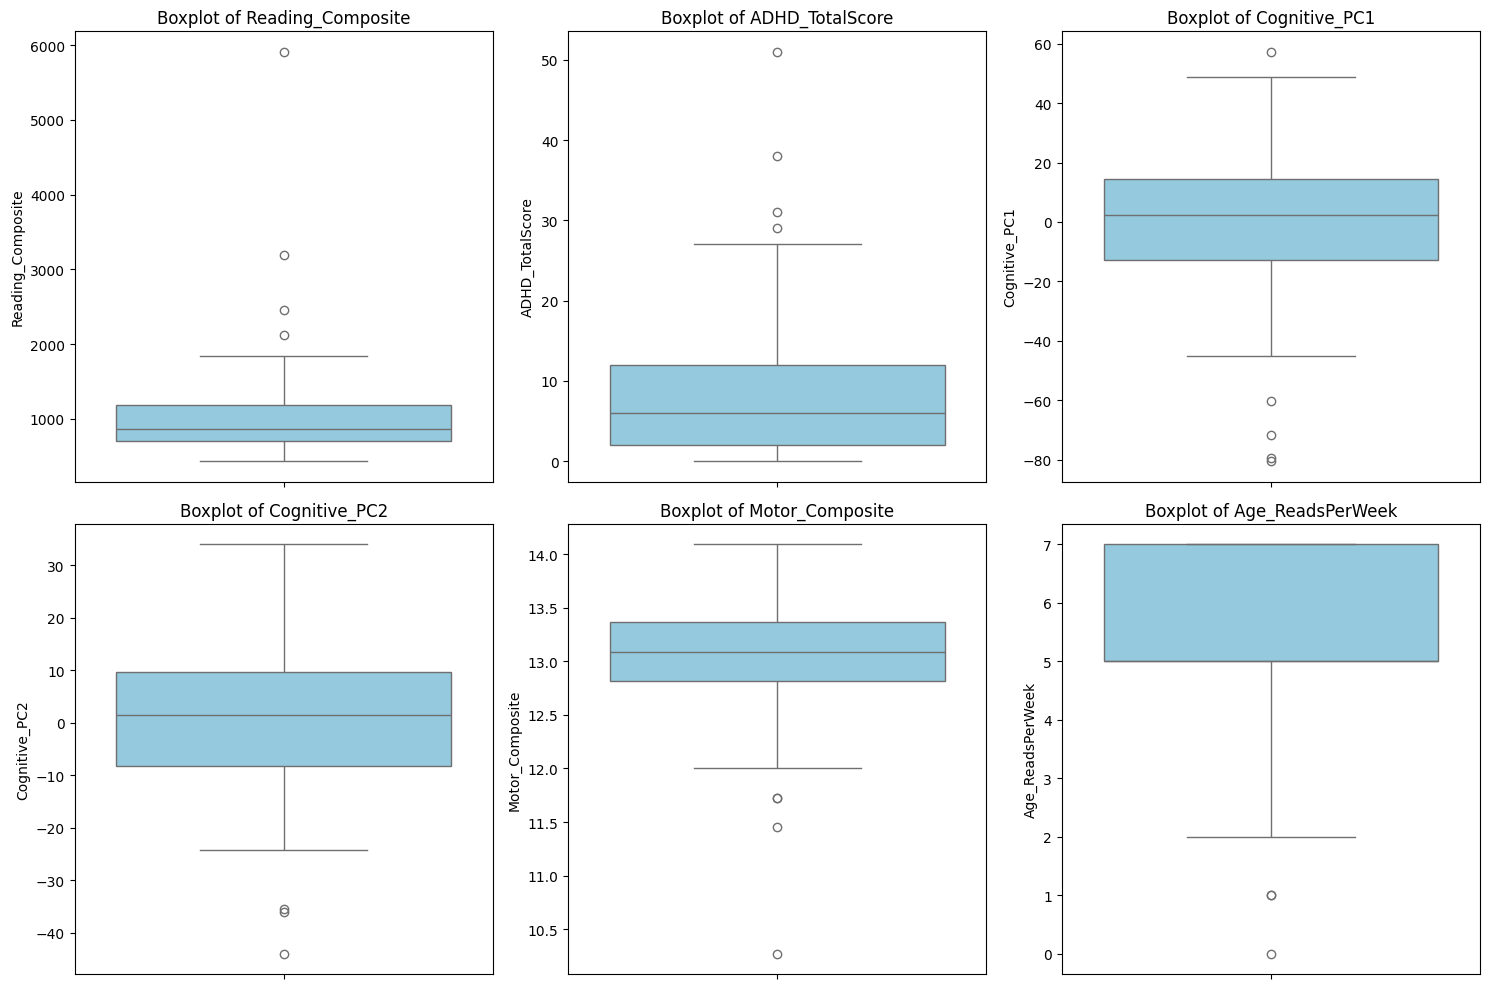

In [48]:
# Visualize outliers

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")  # changed palette -> color
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [49]:
# Detect extreme outliers (Z-score > 3)

z_scores = np.abs(zscore(df[numeric_cols]))
outliers = (z_scores > 3)
print("Outliers detected (True = outlier):")
print(pd.DataFrame(outliers, columns=numeric_cols))

Outliers detected (True = outlier):
    Reading_Composite  ADHD_TotalScore  Cognitive_PC1  Cognitive_PC2  \
0               False            False          False          False   
1               False            False          False          False   
2               False            False          False          False   
3               False            False          False          False   
4               False            False          False          False   
..                ...              ...            ...            ...   
82              False            False          False          False   
83              False            False          False          False   
84              False            False          False          False   
85              False            False          False          False   
86              False             True          False          False   

    Motor_Composite  Age_ReadsPerWeek  
0             False             False  
1             False

In [50]:
from scipy.stats.mstats import winsorize

numeric_cols = ['Reading_Composite', 'ADHD_TotalScore', 'Cognitive_PC1',
                'Cognitive_PC2', 'Motor_Composite', 'Age_ReadsPerWeek']

# Winsorize each numeric column at 1% and 99% percentiles
for col in numeric_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

In [51]:
# Check Z-scores after winsorization
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_cols]))
print("Outliers after winsorization (Z>3):")
print(pd.DataFrame(z_scores > 3, columns=numeric_cols).sum())

Outliers after winsorization (Z>3):
Reading_Composite    2
ADHD_TotalScore      2
Cognitive_PC1        2
Cognitive_PC2        0
Motor_Composite      2
Age_ReadsPerWeek     1
dtype: int64


In [52]:
df_cleaned = df

In [53]:
# Encode categorical variables (already numeric, but ensure consistent)

# Sex: 1=Male, 2=Female
df_cleaned['Sex'] = df_cleaned['Sex'].map({1:'Male', 2:'Female'})
df_cleaned = pd.get_dummies(df_cleaned, columns=['Sex','EnglishAccess'], drop_first=True)

In [54]:
# Normalize numeric features

scaler = StandardScaler()  # Z-score normalization
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])

In [55]:
print("Preprocessed dataset:")
df_cleaned.head()

Preprocessed dataset:


,participant_ID,Reading_Composite,ADHD_TotalScore,Cognitive_PC1,Cognitive_PC2,Motor_Composite,Age_ReadsPerWeek,Sex_Male,EnglishAccess_2.0,EnglishAccess_3.0
0,sub-1002,-0.538559,-0.623216,0.037665,1.485793,0.705830,-0.259564,False,False,False
1,sub-1076,-0.797549,0.964812,-0.384998,-0.039687,0.150946,0.994997,True,False,False
2,sub-1077,-0.405450,0.397659,0.788976,0.316593,0.705830,-0.259564,True,False,False
3,sub-1078,-0.011518,-0.736647,0.483758,-2.988449,-0.218978,-0.259564,True,False,False
4,sub-1079,0.624167,0.057367,-1.043514,0.890570,0.520869,-2.768687,False,False,False


In [56]:
df_cleaned['ADHD_Label'] = (df_cleaned['ADHD_TotalScore'] > 0).astype(int)
df_cleaned['Dyslexia_Label'] = 1
df_cleaned.head()

,participant_ID,Reading_Composite,ADHD_TotalScore,Cognitive_PC1,Cognitive_PC2,Motor_Composite,Age_ReadsPerWeek,Sex_Male,EnglishAccess_2.0,EnglishAccess_3.0,ADHD_Label,Dyslexia_Label
0,sub-1002,-0.538559,-0.623216,0.037665,1.485793,0.705830,-0.259564,False,False,False,0,1
1,sub-1076,-0.797549,0.964812,-0.384998,-0.039687,0.150946,0.994997,True,False,False,1,1
2,sub-1077,-0.405450,0.397659,0.788976,0.316593,0.705830,-0.259564,True,False,False,1,1
3,sub-1078,-0.011518,-0.736647,0.483758,-2.988449,-0.218978,-0.259564,True,False,False,0,1
4,sub-1079,0.624167,0.057367,-1.043514,0.890570,0.520869,-2.768687,False,False,False,1,1


In [57]:
# Finally add multi-label columns
df_cleaned['Dyslexia_Label'] = 1
df_cleaned.head()

,participant_ID,Reading_Composite,ADHD_TotalScore,Cognitive_PC1,Cognitive_PC2,Motor_Composite,Age_ReadsPerWeek,Sex_Male,EnglishAccess_2.0,EnglishAccess_3.0,ADHD_Label,Dyslexia_Label
0,sub-1002,-0.538559,-0.623216,0.037665,1.485793,0.705830,-0.259564,False,False,False,0,1
1,sub-1076,-0.797549,0.964812,-0.384998,-0.039687,0.150946,0.994997,True,False,False,1,1
2,sub-1077,-0.405450,0.397659,0.788976,0.316593,0.705830,-0.259564,True,False,False,1,1
3,sub-1078,-0.011518,-0.736647,0.483758,-2.988449,-0.218978,-0.259564,True,False,False,0,1
4,sub-1079,0.624167,0.057367,-1.043514,0.890570,0.520869,-2.768687,False,False,False,1,1


In [ ]:
# Save to CSV
df_cleaned.to_csv('OpenNeuro_dyslexia_phenomic_Preprocessed_Dataset.csv.csv', index=False)

print("Dataset saved as 'OpenNeuro_dyslexia_phenomic_Preprocessed_Dataset.csv.csv'")

Dataset saved as 'Dyslexia_ADHD_Phenomic_Preprocessed_Dataset.csv'


In [59]:
# Check for null values in the entire dataframe
null_counts = df_cleaned.isnull().sum()

print("Null values in each column:")
print(null_counts)

# Check if there are any nulls at all
if df_cleaned.isnull().values.any():
    print("\nThere are null values in the dataset.")
else:
    print("\nNo null values in the dataset.")


Null values in each column:
participant_ID       0
Reading_Composite    0
ADHD_TotalScore      0
Cognitive_PC1        0
Cognitive_PC2        0
Motor_Composite      0
Age_ReadsPerWeek     0
Sex_Male             0
EnglishAccess_2.0    0
EnglishAccess_3.0    0
ADHD_Label           0
Dyslexia_Label       0
dtype: int64

No null values in the dataset.
